# Attention Sinks — Gemma 4 E2B Analysis

**Hypothesis under test:** Cancedda 2024 claims BOS is a cost-free attention dump (low-norm value vector → no-op).
Our measurement: `exact_share_bos / attn_bos > 1` in full layers would falsify that.

**Data source:** `outputs/full/` (canonical run) or `outputs/smoke/` (smoke test), auto-detected.
Run Stage 1 or Stage 2 from `RUNBOOK.md` before opening this notebook.


In [3]:
%matplotlib inline
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

HERE = Path(".")

def _load_run(run_dir):
    summary_candidates = [
        run_dir / "summary.json",
        run_dir / "smoke_all_summary.json",
        run_dir / "smoke_es_summary.json",
    ]
    parquet_candidates = [
        run_dir / "cases.parquet",
        run_dir / "smoke_all_cases.parquet",
        run_dir / "smoke_es_cases.parquet",
    ]
    index_candidates = [
        run_dir / "prompt_index.jsonl",
        run_dir / "smoke_all_index.jsonl",
        run_dir / "smoke_es_index.jsonl",
    ]
    s = next((p for p in summary_candidates if p.exists()), None)
    c = next((p for p in parquet_candidates if p.exists()), None)
    i = next((p for p in index_candidates   if p.exists()), None)
    if s is None:
        return None, None, None
    summary = json.loads(s.read_text())
    cases   = pd.read_parquet(c) if c else pd.DataFrame()
    idx     = pd.read_json(i, lines=True) if i else pd.DataFrame()
    return summary, cases, idx

summary, cases, prompt_index = None, None, None
for run_name in ("full", "smoke"):
    summary, cases, prompt_index = _load_run(HERE / "outputs" / run_name)
    if summary is not None:
        print(f"Loaded '{run_name}' run")
        break

if summary is None:
    raise FileNotFoundError("No outputs found. Run Stage 1 (smoke) or Stage 2 (full) from RUNBOOK.md first.")

print(f"  prompts : {summary['num_prompts']}")
print(f"  strata  : {', '.join(summary['active_strata'])}")
print(f"  device  : {summary['device']}  dtype: {summary['dtype']}")
print(f"  cases   : {len(cases)} rows  columns: {list(cases.columns)}")


Loaded 'smoke' run
  prompts : 5
  strata  : chat/en, named_entity_recognition/en, named_entity_recognition/es, machine_translation/en-de, machine_translation_evaluation/zh_en
  device  : mps  dtype: bfloat16
  cases   : 6283 rows  columns: ['sample_id', 'source_idx', 'stratum', 'layer', 'layer_type', 'depth_bucket', 'query_pos', 'query_anchor', 'key_pos', 'visible_start', 'visible_end', 'edge_offset', 'query_offset', 'token_id', 'token_piece', 'decoded_token', 'position_group', 'token_type', 'attention_mass_mean', 'score_pre', 'score_resid_exact', 'is_topk_pre', 'is_self', 'is_bos', 'dataset', 'split']


## Validation

In [4]:
v = summary["validation"]
bos_flags = v["sliding_bos_visible_for_late_query"]
bos_rate  = sum(bos_flags) / len(bos_flags) if bos_flags else 0.0

lt   = summary["aggregates"]["layer_type"]
full = lt["full"]
attn_bos_val  = full["attention_overlap_mass_mean"]["bos"]
exact_bos_val = full["anchor_exact_position_partition_share_mean"]["bos"]

checks = [
    ("reconstruction_relative_error",   v["reconstruction_relative_error"],      "< 0.01",  v["reconstruction_relative_error"] < 0.01),
    ("sliding_bos_visible_rate",        bos_rate,                                "≈ 0.000", bos_rate < 0.001),
    ("anchor_exact_negative_count",     float(v["anchor_exact_negative_count"]), "= 0",     v["anchor_exact_negative_count"] == 0),
    ("exact_share_bos > attn_bos (full)", exact_bos_val / max(attn_bos_val, 1e-9), "> 1.0", exact_bos_val > attn_bos_val),
]

print(f"{'Check':<45} {'Value':>10}  {'Target':>10}  Pass")
print("─" * 72)
for name, val, target, ok in checks:
    mark = "✓" if ok else "✗"
    print(f"{name:<45} {val:>10.4f}  {target:>10}  {mark}")


Check                                              Value      Target  Pass
────────────────────────────────────────────────────────────────────────
reconstruction_relative_error                     0.0023      < 0.01  ✓
sliding_bos_visible_rate                          0.0000     ≈ 0.000  ✓
anchor_exact_negative_count                       0.0000         = 0  ✓
exact_share_bos > attn_bos (full)                 1.9306       > 1.0  ✓


## 1. Sliding vs Full — contribution overview

Each bar shows the **share** of `score_pre` (left) and `exact_score` (right) that lands in each position group.
- **pre** = ‖c_pre(q,k)‖ proportional — additive pre-norm contribution magnitude
- **exact** = leave-one-out post-RMSNorm L2 shift — actual residual-stream impact


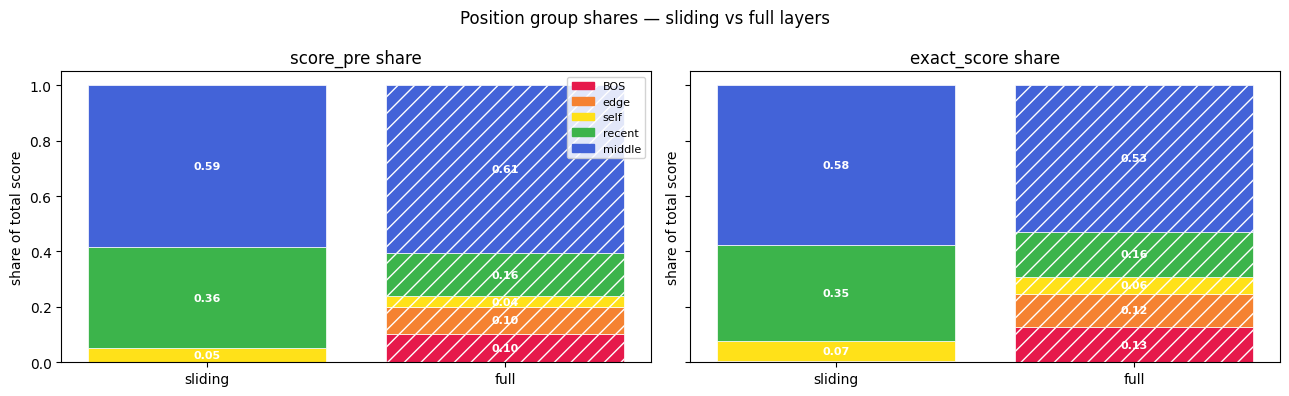


sliding — pre_share_middle: 0.585  exact_share_middle: 0.577
full    — pre_share_bos:    0.103  exact_share_bos:    0.128


In [5]:
GROUPS  = ["bos", "edge", "self", "recent_nonself", "middle"]
COLORS  = ["#e6194b", "#f58231", "#ffe119", "#3cb44b", "#4363d8"]
LABELS  = ["BOS", "edge", "self", "recent", "middle"]

def get_shares(bucket_key, metric):
    b = lt[bucket_key]
    if metric == "pre":
        return [b["pre_position_partition_share_mean"][g]  for g in GROUPS]
    return [b["anchor_exact_position_partition_share_mean"][g] for g in GROUPS]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, metric, title in zip(axes, ["pre", "exact"], ["score_pre share", "exact_score share"]):
    for scope, bar_x, hatch in [("sliding", 0, ""), ("full", 1, "//")]:
        shares = get_shares(scope, metric)
        bottom = 0.0
        for g, s, c, lab in zip(GROUPS, shares, COLORS, LABELS):
            ax.bar(bar_x, s, bottom=bottom, color=c, hatch=hatch,
                   label=f"{lab}" if bar_x == 0 else None, edgecolor="white", linewidth=0.5)
            if s > 0.03:
                ax.text(bar_x, bottom + s/2, f"{s:.2f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
            bottom += s
    ax.set_xticks([0, 1]); ax.set_xticklabels(["sliding", "full"])
    ax.set_ylabel("share of total score"); ax.set_title(title)
    ax.set_ylim(0, 1.05)

handles = [plt.Rectangle((0,0),1,1, color=c, label=l) for c, l in zip(COLORS, LABELS)]
axes[0].legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.85)
fig.suptitle("Position group shares — sliding vs full layers", fontsize=12)
plt.tight_layout(); plt.show()

print("\nsliding — pre_share_middle:", f"{lt['sliding']['pre_position_partition_share_mean']['middle']:.3f}",
      " exact_share_middle:", f"{lt['sliding']['anchor_exact_position_partition_share_mean']['middle']:.3f}")
print("full    — pre_share_bos:   ", f"{lt['full']['pre_position_partition_share_mean']['bos']:.3f}",
      " exact_share_bos:   ", f"{lt['full']['anchor_exact_position_partition_share_mean']['bos']:.3f}")


## 2. Cancedda Test — BOS as a no-op?

Cancedda 2024: BOS value vector has low norm → attention mass that lands there produces no residual change.

**Falsification condition:** `exact_share_bos > attn_bos` in full layers.
If BOS were truly a no-op dump, its share of residual impact would be *less* than its share of attention mass.


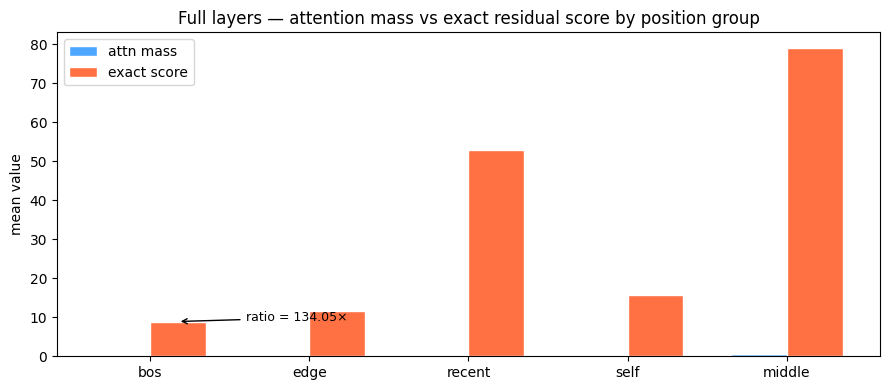

BOS  attn=0.0665  exact=8.9092  ratio=134.05×
→  ratio > 1 means BOS delivers MORE residual impact per unit attention than average — not a no-op


In [6]:
groups_overlap = ["bos", "edge", "recent", "self", "middle"]
attn_full  = [full["attention_overlap_mass_mean"][g]        for g in groups_overlap]
exact_full = [full["anchor_exact_overlap_mean"][g]          for g in groups_overlap]

x = np.arange(len(groups_overlap))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - w/2, attn_full,  w, label="attn mass",   color="#4da6ff", edgecolor="white")
b2 = ax.bar(x + w/2, exact_full, w, label="exact score", color="#ff7043", edgecolor="white")

ax.set_xticks(x); ax.set_xticklabels(groups_overlap)
ax.set_ylabel("mean value"); ax.set_title("Full layers — attention mass vs exact residual score by position group")
ax.legend()

# annotate ratio for BOS
bos_idx = 0
ratio = exact_full[bos_idx] / max(attn_full[bos_idx], 1e-9)
ax.annotate(f"ratio = {ratio:.2f}×", xy=(bos_idx + w/2, exact_full[bos_idx]),
            xytext=(bos_idx + 0.6, exact_full[bos_idx] + 0.01),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)

plt.tight_layout(); plt.show()
print(f"BOS  attn={attn_full[0]:.4f}  exact={exact_full[0]:.4f}  ratio={ratio:.2f}×")
print("→  ratio > 1 means BOS delivers MORE residual impact per unit attention than average — not a no-op")


## 3. Per-layer breakdown

Exact score share for each group across all 35 layers. S = sliding, F = full.
Watch how BOS share spikes on full layers (4, 9, 14, 19, 24, 29, 34) and collapses to zero on sliding layers.


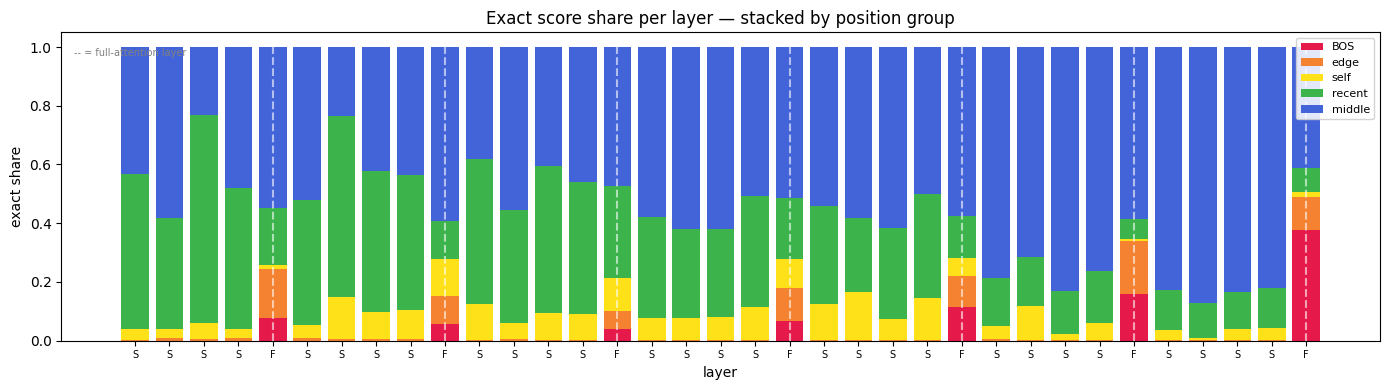

In [7]:
per_layer = summary["aggregates"]["per_layer"]
FULL_LAYERS = {4, 9, 14, 19, 24, 29, 34}
n_layers = len(per_layer)

bos_exact    = [per_layer[str(i)]["anchor_exact_position_partition_share_mean"]["bos"]          for i in range(n_layers)]
edge_exact   = [per_layer[str(i)]["anchor_exact_position_partition_share_mean"]["edge"]         for i in range(n_layers)]
recent_exact = [per_layer[str(i)]["anchor_exact_position_partition_share_mean"]["recent_nonself"] for i in range(n_layers)]
self_exact   = [per_layer[str(i)]["anchor_exact_position_partition_share_mean"]["self"]         for i in range(n_layers)]
mid_exact    = [per_layer[str(i)]["anchor_exact_position_partition_share_mean"]["middle"]       for i in range(n_layers)]

xs = np.arange(n_layers)
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(xs, bos_exact,    label="BOS",    color="#e6194b")
ax.bar(xs, edge_exact,   bottom=np.array(bos_exact),                                    label="edge",   color="#f58231")
ax.bar(xs, self_exact,   bottom=np.array(bos_exact)+np.array(edge_exact),               label="self",   color="#ffe119")
ax.bar(xs, recent_exact, bottom=np.array(bos_exact)+np.array(edge_exact)+np.array(self_exact), label="recent", color="#3cb44b")
bot = np.array(bos_exact)+np.array(edge_exact)+np.array(self_exact)+np.array(recent_exact)
ax.bar(xs, mid_exact,    bottom=bot,                                                     label="middle", color="#4363d8")

for i in FULL_LAYERS:
    ax.axvline(i, color="white", linewidth=1.5, linestyle="--", alpha=0.6)
ax.text(0.01, 0.95, "-- = full-attention layer", transform=ax.transAxes, fontsize=7, va="top", color="gray")

ax.set_xlabel("layer"); ax.set_ylabel("exact share"); ax.set_ylim(0, 1.05)
ax.set_title("Exact score share per layer — stacked by position group")
ax.set_xticks(xs); ax.set_xticklabels(
    ["F" if i in FULL_LAYERS else "S" for i in range(n_layers)], fontsize=7
)
ax.legend(loc="upper right", fontsize=8, framealpha=0.85)
plt.tight_layout(); plt.show()


## 4. Depth evolution in sliding layers

Do early, mid, and late sliding layers behave differently?


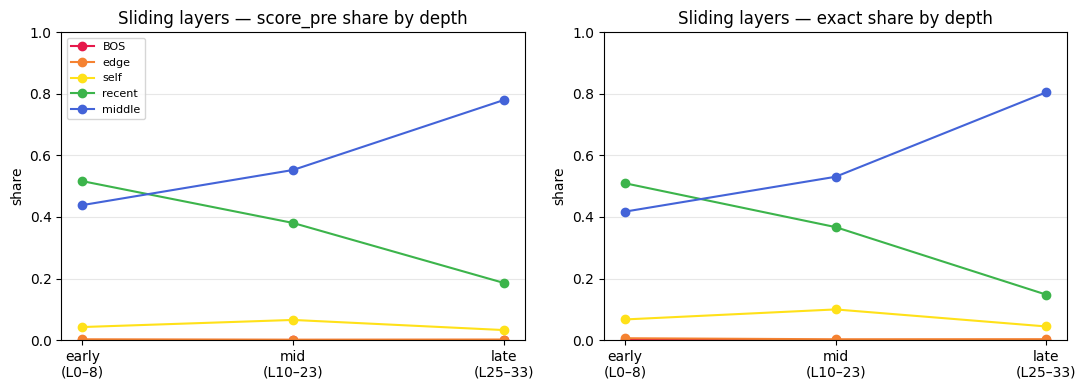

In [8]:
db = summary["aggregates"]["depth_bucket"]
buckets = ["early_sliding", "mid_sliding", "late_sliding"]
bucket_labels = ["early\n(L0–8)", "mid\n(L10–23)", "late\n(L25–33)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, title in zip(axes, ["pre", "exact"], ["score_pre share", "exact share"]):
    for g, c, lab in zip(GROUPS, COLORS, LABELS):
        vals = []
        for bk in buckets:
            if metric == "pre":
                vals.append(db[bk]["pre_position_partition_share_mean"][g])
            else:
                vals.append(db[bk]["anchor_exact_position_partition_share_mean"][g])
        ax.plot(range(len(buckets)), vals, marker="o", color=c, label=lab)
    ax.set_xticks(range(len(buckets))); ax.set_xticklabels(bucket_labels)
    ax.set_ylabel("share"); ax.set_title(f"Sliding layers — {title} by depth")
    ax.set_ylim(0, 1.0); ax.grid(axis="y", alpha=0.3)

axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 5. Case study — top contributing positions

From the parquet: for each anchor query, we recorded the top-k positions sorted by `score_pre`.
Here we compare `score_pre` vs `score_resid_exact` for different position groups to see
whether high pre-score translates to high residual impact.


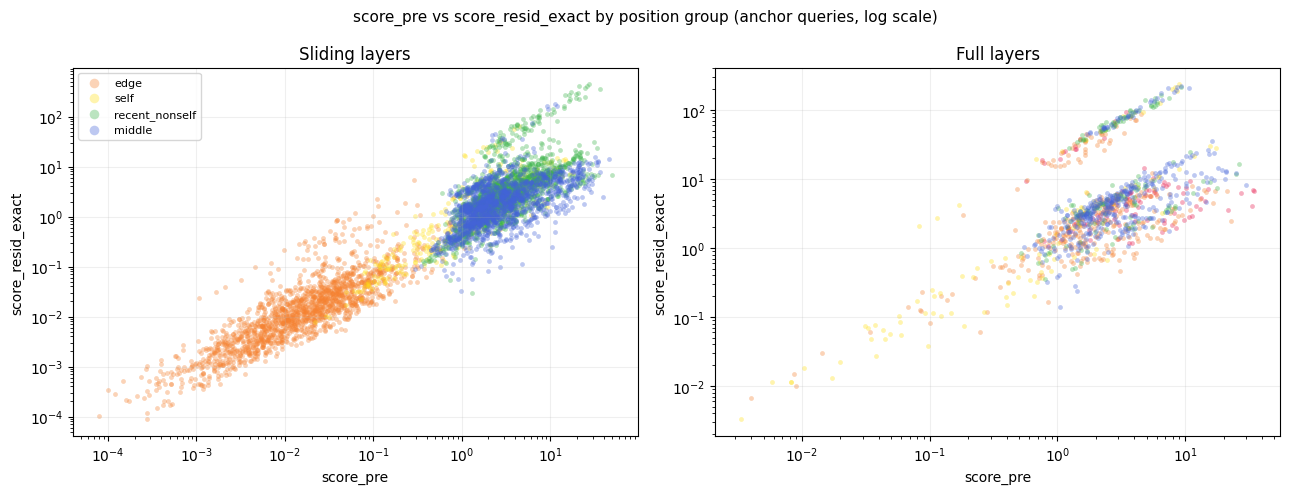


Correlation (log-space) score_pre ~ score_resid_exact:
  sliding : r = 0.946  (n=5225)
  full    : r = 0.654  (n=1058)


In [9]:
if cases.empty:
    print("No cases parquet found.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    group_colors = {"bos": "#e6194b", "edge": "#f58231", "self": "#ffe119",
                    "recent_nonself": "#3cb44b", "middle": "#4363d8"}

    for ax, ltype, title in zip(axes, ["sliding_attention", "full_attention"], ["Sliding layers", "Full layers"]):
        sub = cases[cases["layer_type"] == ltype]
        for grp, color in group_colors.items():
            g = sub[sub["position_group"] == grp]
            if len(g) == 0:
                continue
            ax.scatter(g["score_pre"], g["score_resid_exact"], c=color,
                       label=grp, alpha=0.35, s=12, linewidths=0)
        ax.set_xlabel("score_pre"); ax.set_ylabel("score_resid_exact")
        ax.set_title(title); ax.set_xscale("log"); ax.set_yscale("log")
        ax.grid(alpha=0.2)

    axes[0].legend(fontsize=8, markerscale=2)
    fig.suptitle("score_pre vs score_resid_exact by position group (anchor queries, log scale)", fontsize=11)
    plt.tight_layout(); plt.show()

    print("\nCorrelation (log-space) score_pre ~ score_resid_exact:")
    for ltype in ["sliding_attention", "full_attention"]:
        sub = cases[(cases["layer_type"] == ltype) & (cases["score_pre"] > 0) & (cases["score_resid_exact"] > 0)]
        if len(sub) > 2:
            r = np.corrcoef(np.log(sub["score_pre"]), np.log(sub["score_resid_exact"]))[0, 1]
            print(f"  {ltype.split('_')[0]:8s}: r = {r:.3f}  (n={len(sub)})")


## 6. Top positions per stratum

For each stratum, show the positions with highest mean `score_resid_exact` at anchor queries.


In [10]:
if cases.empty:
    print("No cases parquet.")
else:
    strata = cases["stratum"].unique()
    for stratum in sorted(strata):
        sub = cases[cases["stratum"] == stratum]
        top = (sub.groupby(["layer", "position_group", "decoded_token"])
                  .agg(mean_exact=("score_resid_exact", "mean"), n=("score_resid_exact", "count"))
                  .reset_index()
                  .sort_values("mean_exact", ascending=False)
                  .head(8))
        print(f"\n── {stratum} ──")
        print(top.to_string(index=False))



── chat/en ──
 layer position_group decoded_token  mean_exact  n
     0 recent_nonself         Quick  350.079224  1
     0 recent_nonself             '  246.196548  1
     0 recent_nonself           for  218.825104  2
    14         middle            '.  140.993454  1
    14 recent_nonself            To  130.951431  1
    14 recent_nonself         Quick  116.103951  1
    14 recent_nonself           for  106.690414  2
    14 recent_nonself     available   97.978706  1

── machine_translation/en-de ──
 layer position_group decoded_token  mean_exact  n
     0 recent_nonself       <turn|>  418.064453  1
     0 recent_nonself         hätte  291.172821  1
     0 recent_nonself         years  280.530029  1
    14 recent_nonself       <turn|>  215.987030  1
     0 recent_nonself    classified  205.414856  1
    14         middle         model  195.265121  1
    14           self            as  189.117172  1
     0         middle         model  163.058182  1

── machine_translation_evaluation